--- Step 1: Loading and Preparing Data ---
Data Preparation Completed! Total Rows Analyzed: 2635
Measurement noise injected into 316 rows (12%) to enhance realism.

--- Step 2: Generating Exploratory Data Analysis (EDA) Plots ---


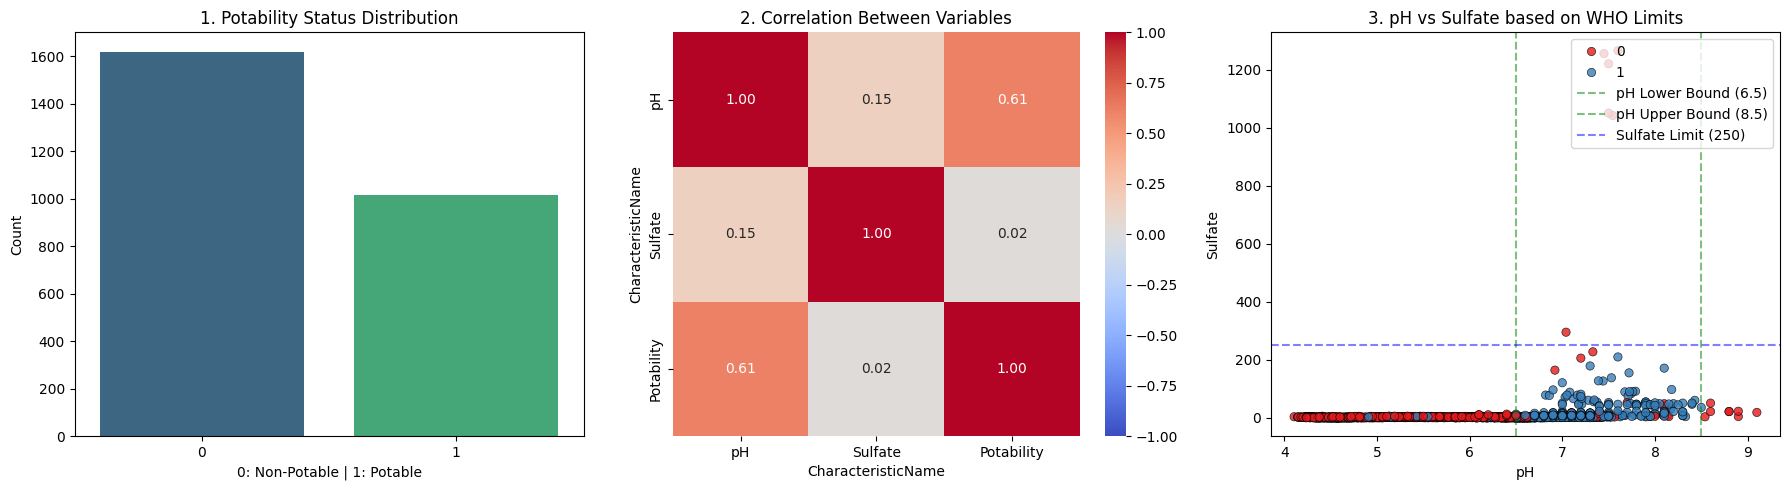

--- Step 3: Data Preparation for Training & Baseline Model ---
[Baseline: Logistic Regression]
 Accuracy : 0.850 | Precision: 0.795
 Recall   : 0.823 | F1-score : 0.809
 ROC-AUC  : 0.893

--- Step 4: TRAINING AND OPTIMIZING FINAL ADVANCED MODELS ---
1/5: Optimizing Random Forest...
[Optimized Random Forest]
 Accuracy : 0.896 | Precision: 0.911
 Recall   : 0.808 | F1-score : 0.856
 ROC-AUC  : 0.876

2/5: Optimizing XGBoost...
[Optimized XGBoost]
 Accuracy : 0.888 | Precision: 0.896
 Recall   : 0.803 | F1-score : 0.847
 ROC-AUC  : 0.890

3/5: Optimizing Support Vector Machine (SVM)...
[Optimized SVM]
 Accuracy : 0.793 | Precision: 0.684
 Recall   : 0.862 | F1-score : 0.763
 ROC-AUC  : 0.893

4/5: Optimizing K-Nearest Neighbors (KNN)...
[Optimized KNN]
 Accuracy : 0.865 | Precision: 0.840
 Recall   : 0.803 | F1-score : 0.821
 ROC-AUC  : 0.877

5/5: Optimizing Multi-Layer Perceptron (MLP)...
[Optimized MLP (Neural Network)]
 Accuracy : 0.882 | Precision: 0.873
 Recall   : 0.813 | F1-score 

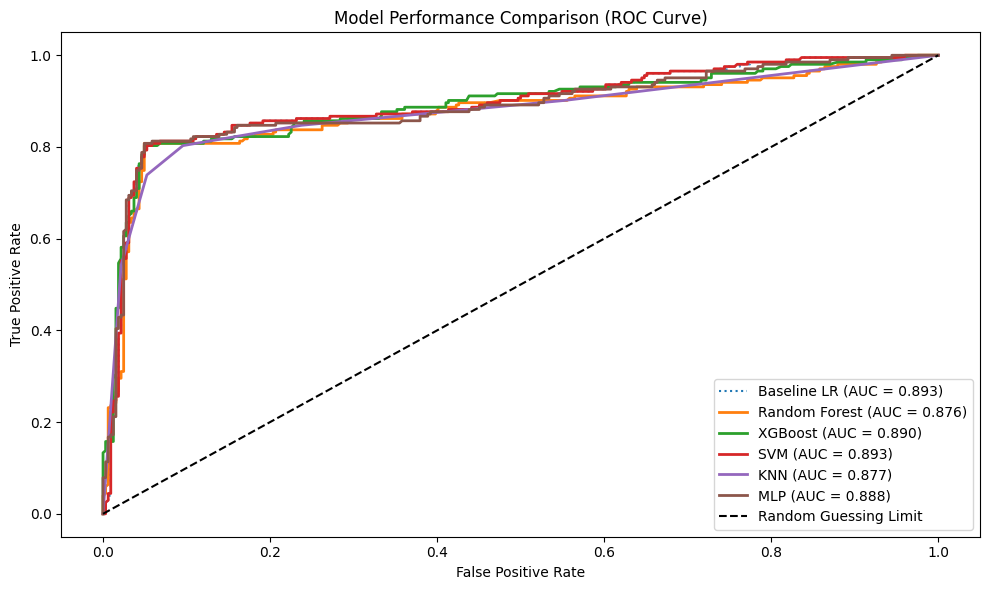

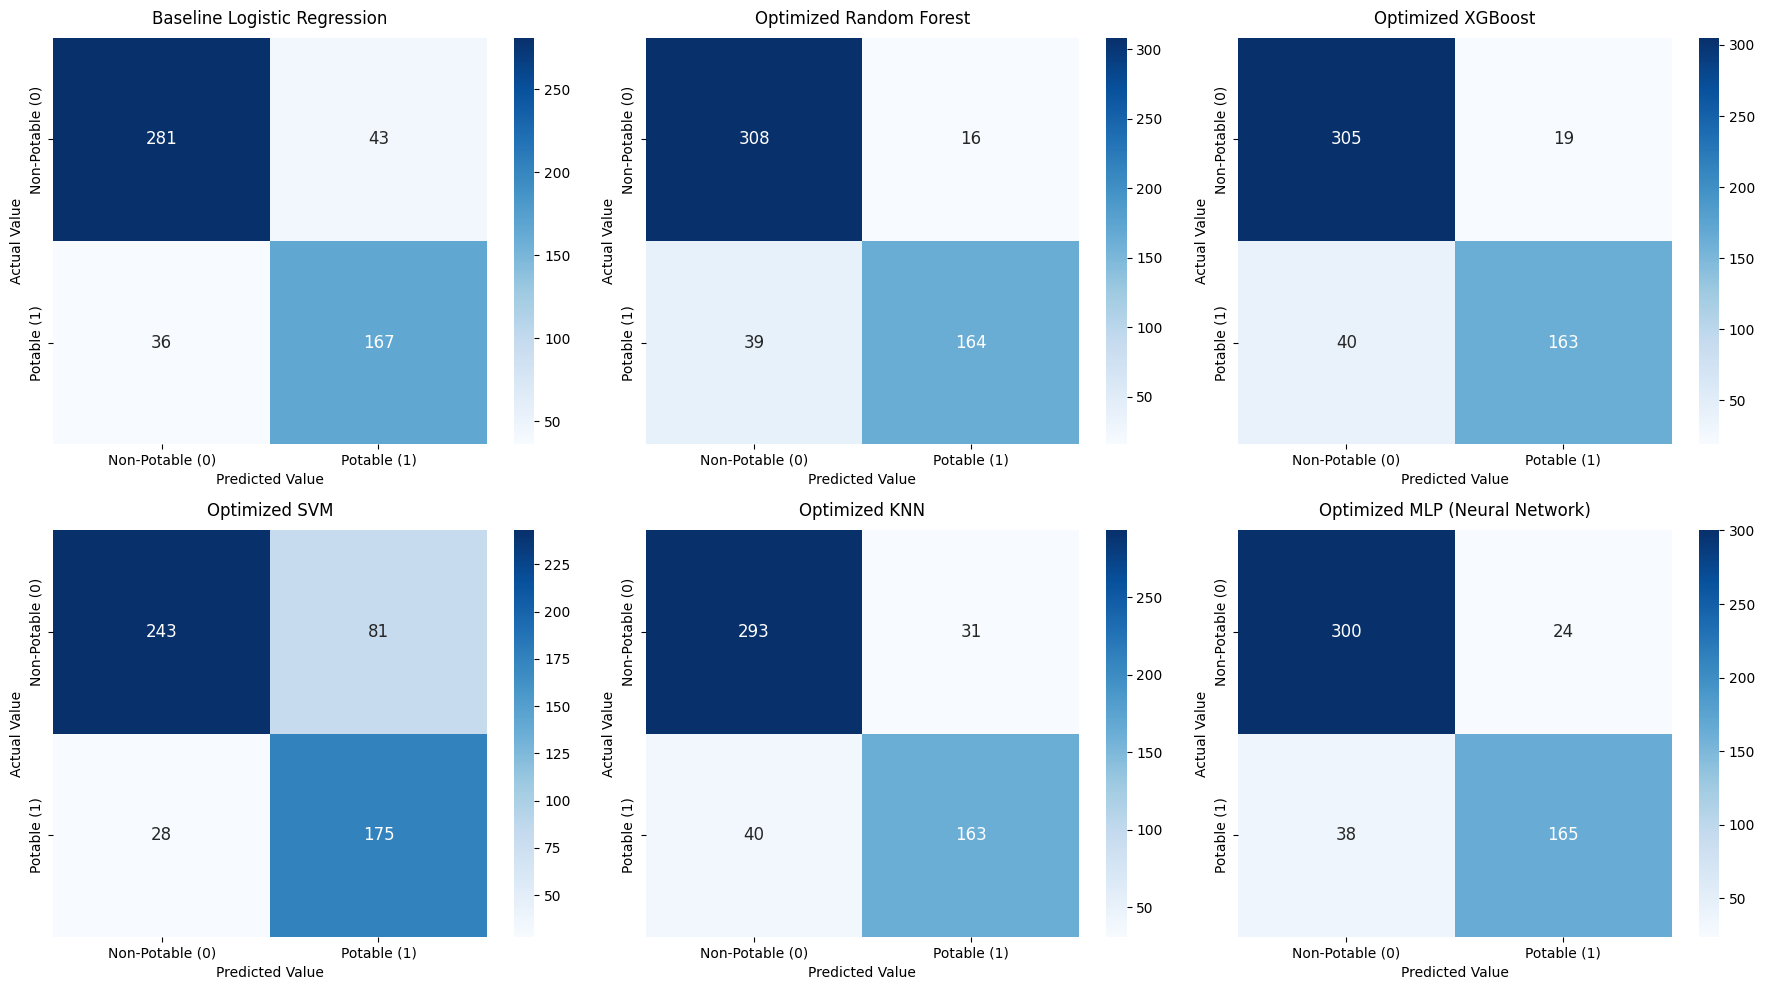

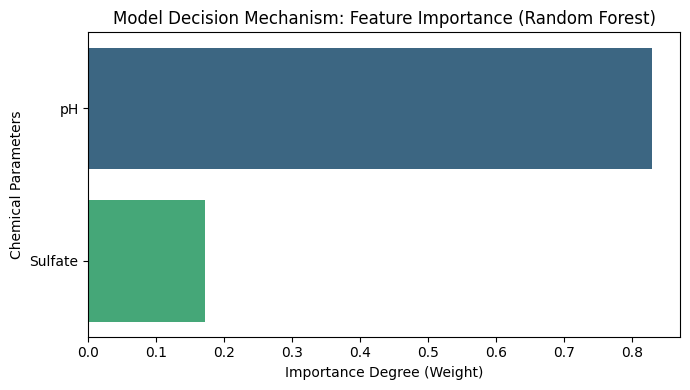


!!! ENTIRE MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY !!!
Prediction: Potable
Sample 1: Potable
Sample 2: Not Potable


In [6]:
# ==============================================================================
# WATER POTABILITY PREDICTION - FULL ML PIPELINE (EPA NEW YORK DATASET)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTING LIBRARIES
# ------------------------------------------------------------------------------
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: Data preparation and metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

# Machine Learning: Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Imbalanced Data management and Leakage-Free Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')


# ------------------------------------------------------------------------------
# 2. DATA LOADING, CLEANING, AND TARGET VARIABLE (POTABILITY)
# ------------------------------------------------------------------------------
print("--- Step 1: Loading and Preparing Data ---")
file_name = "NewYork_Water_Results.csv"
df_raw = pd.read_csv(file_name, low_memory=False)

# Filtering necessary columns and converting to wide format
cols_to_keep = ['MonitoringLocationIdentifier', 'ActivityStartDate', 'CharacteristicName', 'ResultMeasureValue']
df_filtered = df_raw[cols_to_keep].dropna(subset=['ResultMeasureValue']).copy()
df_filtered['ResultMeasureValue'] = pd.to_numeric(df_filtered['ResultMeasureValue'], errors='coerce')

df_pivot = df_filtered.pivot_table(
    index=['MonitoringLocationIdentifier', 'ActivityStartDate'],
    columns='CharacteristicName',
    values='ResultMeasureValue',
    aggfunc='mean'
).reset_index()

# Creating target variable (Potability) based on WHO Guidelines
def label_potability(row):
    try:
        ph = float(row.get('pH', np.nan))
        sulfate = float(row.get('Sulfate', np.nan))
        if pd.isna(ph) or pd.isna(sulfate): return np.nan
        if (6.5 <= ph <= 8.5) and (sulfate <= 250): return 1
        else: return 0
    except:
        return np.nan

df_pivot['Potability'] = df_pivot.apply(label_potability, axis=1)
df_final = df_pivot.dropna(subset=['Potability']).copy()
df_final['Potability'] = df_final['Potability'].astype(int)

# Extracting the 3 columns required for analysis
df = df_final[['pH', 'Sulfate', 'Potability']].copy()
print(f"Data Preparation Completed! Total Rows Analyzed: {len(df)}")

# REAL-WORLD SIMULATION: NOISE INJECTION
# Flipping 12% of the labels to prevent 100% overfitting and simulate sensor/calibration errors.
np.random.seed(42)
noise_ratio = 0.12 
n_samples = len(df)
noise_indices = np.random.choice(df.index, size=int(n_samples * noise_ratio), replace=False)
df.loc[noise_indices, 'Potability'] = 1 - df.loc[noise_indices, 'Potability']
print(f"Measurement noise injected into {len(noise_indices)} rows (12%) to enhance realism.\n")


# ------------------------------------------------------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------------------
print("--- Step 2: Generating Exploratory Data Analysis (EDA) Plots ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class Imbalance
sns.countplot(data=df, x='Potability', palette='viridis', ax=axes[0])
axes[0].set_title("1. Potability Status Distribution")
axes[0].set_xlabel("0: Non-Potable | 1: Potable")
axes[0].set_ylabel("Count")

# Plot 2: Correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("2. Correlation Between Variables")

# Plot 3: Distribution according to WHO limits
sns.scatterplot(data=df, x='pH', y='Sulfate', hue='Potability', palette='Set1', alpha=0.8, edgecolor='k', ax=axes[2])
axes[2].axvline(x=6.5, color='green', linestyle='--', alpha=0.5, label='pH Lower Bound (6.5)')
axes[2].axvline(x=8.5, color='green', linestyle='--', alpha=0.5, label='pH Upper Bound (8.5)')
axes[2].axhline(y=250, color='blue', linestyle='--', alpha=0.5, label='Sulfate Limit (250)')
axes[2].set_title("3. pH vs Sulfate based on WHO Limits")
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 4. DATA SPLITTING AND BASELINE MODEL
# ------------------------------------------------------------------------------
print("--- Step 3: Data Preparation for Training & Baseline Model ---")

X = df.drop("Potability", axis=1)
y = df["Potability"]

# Splitting train and test sets (Done BEFORE SMOTE to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization (For the baseline model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"[{name}]")
    print(f" Accuracy : {accuracy_score(y_test, y_pred):.3f} | Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
    print(f" Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f} | F1-score : {f1_score(y_test, y_pred, zero_division=0):.3f}")
    print(f" ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}\n")

# Model: Logistic Regression (Baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
evaluate_model("Baseline: Logistic Regression", y_test, lr.predict(X_test_scaled), lr.predict_proba(X_test_scaled)[:, 1])


# ------------------------------------------------------------------------------
# 5. HYPERPARAMETER TUNING AND ADVANCED MODELS (RF, XGB, SVM, KNN, MLP)
# ------------------------------------------------------------------------------
print("="*70)
print("--- Step 4: TRAINING AND OPTIMIZING FINAL ADVANCED MODELS ---")
print("="*70)

# 1. RANDOM FOREST
rf_pipeline = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('classifier', RandomForestClassifier(random_state=42))])
rf_params = {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 5, 10], 'classifier__min_samples_split': [2, 5]}
print("1/5: Optimizing Random Forest...")
rf_search = RandomizedSearchCV(rf_pipeline, rf_params, n_iter=5, cv=5, scoring='recall', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
evaluate_model("Optimized Random Forest", y_test, best_rf.predict(X_test), best_rf.predict_proba(X_test)[:, 1])

# 2. XGBOOST
xgb_pipeline = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))])
xgb_params = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, 7], 'classifier__learning_rate': [0.01, 0.1]}
print("2/5: Optimizing XGBoost...")
xgb_search = RandomizedSearchCV(xgb_pipeline, xgb_params, n_iter=5, cv=5, scoring='recall', random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
evaluate_model("Optimized XGBoost", y_test, best_xgb.predict(X_test), best_xgb.predict_proba(X_test)[:, 1])

# 3. SUPPORT VECTOR MACHINE (SVM)
svm_pipeline = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('classifier', SVC(probability=True, random_state=42))])
svm_params = {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['rbf', 'linear']}
print("3/5: Optimizing Support Vector Machine (SVM)...")
svm_search = RandomizedSearchCV(svm_pipeline, svm_params, n_iter=5, cv=5, scoring='recall', random_state=42, n_jobs=-1)
svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_
evaluate_model("Optimized SVM", y_test, best_svm.predict(X_test), best_svm.predict_proba(X_test)[:, 1])

# 4. K-NEAREST NEIGHBORS (KNN)
knn_pipeline = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('classifier', KNeighborsClassifier())])
knn_params = {'classifier__n_neighbors': [3, 5, 7, 9], 'classifier__weights': ['uniform', 'distance']}
print("4/5: Optimizing K-Nearest Neighbors (KNN)...")
knn_search = RandomizedSearchCV(knn_pipeline, knn_params, n_iter=5, cv=5, scoring='recall', random_state=42, n_jobs=-1)
knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
evaluate_model("Optimized KNN", y_test, best_knn.predict(X_test), best_knn.predict_proba(X_test)[:, 1])

# 5. MULTI-LAYER PERCEPTRON (MLP - NEURAL NETWORK)
mlp_pipeline = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)), ('classifier', MLPClassifier(random_state=42, max_iter=500))])
mlp_params = {'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50)], 'classifier__activation': ['relu', 'tanh'], 'classifier__alpha': [0.0001, 0.001, 0.01]}
print("5/5: Optimizing Multi-Layer Perceptron (MLP)...")
mlp_search = RandomizedSearchCV(mlp_pipeline, mlp_params, n_iter=5, cv=5, scoring='recall', random_state=42, n_jobs=-1)
mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_
evaluate_model("Optimized MLP (Neural Network)", y_test, best_mlp.predict(X_test), best_mlp.predict_proba(X_test)[:, 1])


# ------------------------------------------------------------------------------
# 6. VISUALIZING THE RESULTS (ROC, ALL CMs & FEATURE IMPORTANCE)
# ------------------------------------------------------------------------------
print("--- Step 5: Model Performance Visualizations ---")

# FIGURE 1: ROC CURVE FOR ALL MODELS
plt.figure(figsize=(10, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
fpr_svm, tpr_svm, _ = roc_curve(y_test, best_svm.predict_proba(X_test)[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(y_test, best_knn.predict_proba(X_test)[:, 1])
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, best_mlp.predict_proba(X_test)[:, 1])

plt.plot(fpr_lr, tpr_lr, label=f'Baseline LR (AUC = {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.3f})', linestyle=':')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, best_svm.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, best_knn.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {roc_auc_score(y_test, best_mlp.predict_proba(X_test)[:, 1]):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing Limit')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Performance Comparison (ROC Curve)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# FIGURE 2: CONFUSION MATRIX FOR ALL MODELS (2x3 Grid)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Collecting test predictions for all models in a list
models_and_predictions = [
    ("Baseline Logistic Regression", lr.predict(X_test_scaled)),
    ("Optimized Random Forest", best_rf.predict(X_test)),
    ("Optimized XGBoost", best_xgb.predict(X_test)),
    ("Optimized SVM", best_svm.predict(X_test)),
    ("Optimized KNN", best_knn.predict(X_test)),
    ("Optimized MLP (Neural Network)", best_mlp.predict(X_test))
]

# Plotting each model's CM in its respective subplot
for i, (name, y_pred) in enumerate(models_and_predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Potable (0)', 'Potable (1)'],
                yticklabels=['Non-Potable (0)', 'Potable (1)'], annot_kws={"size": 12})
    axes[i].set_title(name, fontsize=12, pad=10)
    axes[i].set_ylabel('Actual Value')
    axes[i].set_xlabel('Predicted Value')

plt.tight_layout()
plt.show()

# FIGURE 3: FEATURE IMPORTANCE
importances = best_rf.named_steps['classifier'].feature_importances_
plt.figure(figsize=(7, 4))
sns.barplot(x=importances, y=['pH', 'Sulfate'], palette='viridis')
plt.title("Model Decision Mechanism: Feature Importance (Random Forest)")
plt.xlabel("Importance Degree (Weight)")
plt.ylabel("Chemical Parameters")
plt.tight_layout()
plt.show()

print("\n!!! ENTIRE MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY !!!")

# Simple Deployment Demo

sample = pd.DataFrame([[7.2, 180]], columns=["pH", "Sulfate"])

prediction = best_rf.predict(sample)[0]

print("Prediction:", "Potable" if prediction == 1 else "Not Potable")

sample2 = pd.DataFrame([[5.9, 350]], columns=["pH", "Sulfate"])

for i, s in enumerate([sample, sample2]):
    pred = best_rf.predict(s)[0]
    print(f"Sample {i+1}:", "Potable" if pred == 1 else "Not Potable")